In [1]:
# 💡 Summary in 1 sentence each:

# RMSE: Focus on large errors, lower = better.

# MAE: Average error, lower = better.

# MAPE: Percentage error, lower = better.

# R²: How well model explains variation, closer to 1 = better.

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from IPython.display import clear_output
import requests

I0000 00:00:1774406762.860886   98089 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
# ================= CONFIG =================
BASE_DIR   = "../STOCK-EVALUATION-DATA-FIGURE/"
MODELS_DIR = "../DATA-HTML-STOCK/Models"

TIME_STEPS  = 60
dropout     = 0.2
neuron      = 64
lr          = 0.001
batchsize   = 32
epochIs     = 100
patience    = 15

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# ================= DATA =================
companyDetails = pd.read_csv("../DATA-HTML-STOCK/NEPSECompany/NEPSECompanyExtractor.csv")
symbols = companyDetails["Symbol"]

stock_ignored = ["CORBLP", "GFCLPO", "HBLPO", "LFCPO", "SBIPO", "GABLPO", "AMFIPO", "NMLBS", "ILFCPO", "JSLBBP"]

stock_no_news = ["HATHPO", "BUDBLP", "CFCLPO", "CORBLP", "EBLPO", "HAMROP", "HGIPO", "JFLPO", "JBNLPO",
                 "KADBLP", "KNBLPO", "CEFLPO", "LBLPO", "MFILPO", "MIDBLP", "NBBLPO", "NABBPO", "NBBPO",
                 "PFLPO", "PRINPO", "PURBLP", "SBBLJP", "SIFCPO", "SILPO", "SMFDBP", "SYFLPO", "TNBLPO",
                 "TDBLPO", "UFLPO", "WDBLPO", "WMBFPO", "HLBSLP"]

needCompareModel = ["ADBL", "BARUN", "API", "NABIL", "NICA", "NTC"]

In [5]:
# ================= FUNCTIONS =================
def create_sequences(dataset, time_steps=60):
    X, y = [], []
    for i in range(time_steps, len(dataset)):
        X.append(dataset[i-time_steps:i])
        y.append(dataset[i, 0])  # predict Close only
    return np.array(X), np.array(y)


def build_model(time_steps, n_features):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(time_steps, n_features)),
        Dropout(0.2),
        LSTM(64),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
    model.summary()
    return model



===== Processing ADBL =====


E0000 00:00:1774406788.093680   98089 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
/mnt/d/spa/python/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,241 (196.25 KB)

 Trainable params: 50,241 (196.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 0.0096 - val_loss: 3.9500e-04
Epoch 2/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0020 - val_loss: 2.1103e-04
Epoch 3/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0018 - val_loss: 2.6205e-04
Epoch 4/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0018 - val_loss: 2.3052e-04
Epoch 5/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0015 - val_loss: 2.3248e-04
Epoch 6/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0014 - val_loss: 1.7946e-04
Epoch 7/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0013 - val_loss: 1.9010e-04
Epoch 8/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0012 - val_loss: 1.5458e-04
Epoch 9/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0011 - val_loss: 2.4421e-04
Epoch 10/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0013 - val_loss: 2.3159e-04
Epoch 11/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0011 - val_loss: 1.6860e-04
Epoch 12

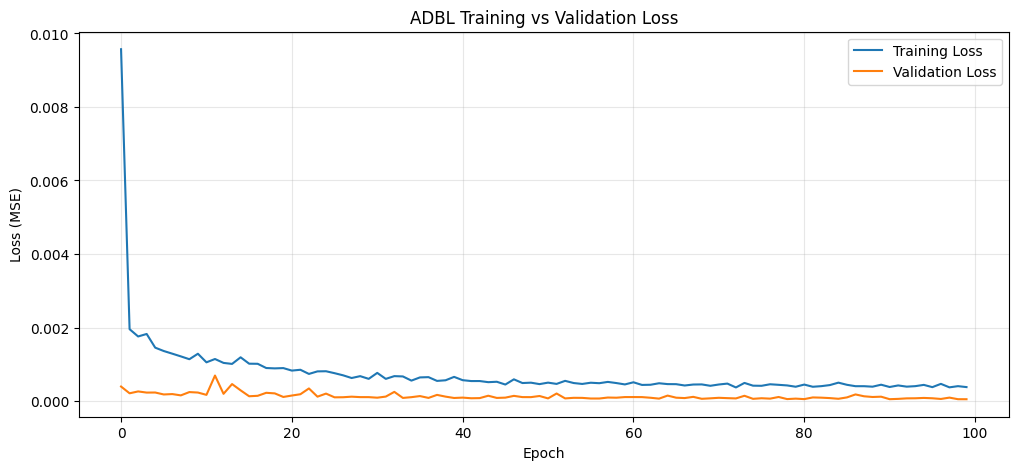

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step
MSE:32.74 RMSE:5.72 MAE:4.00 MAPE:1.29% R2:0.9821


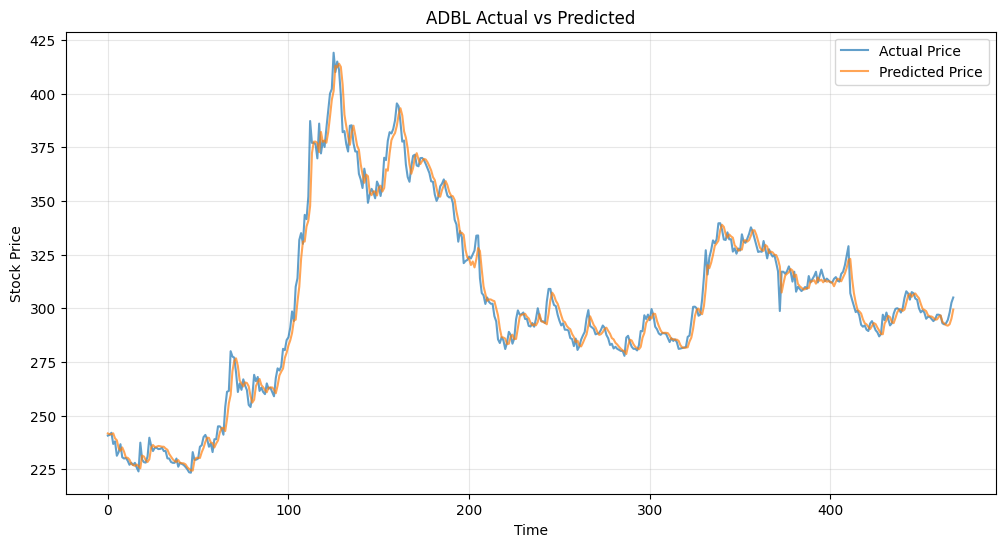

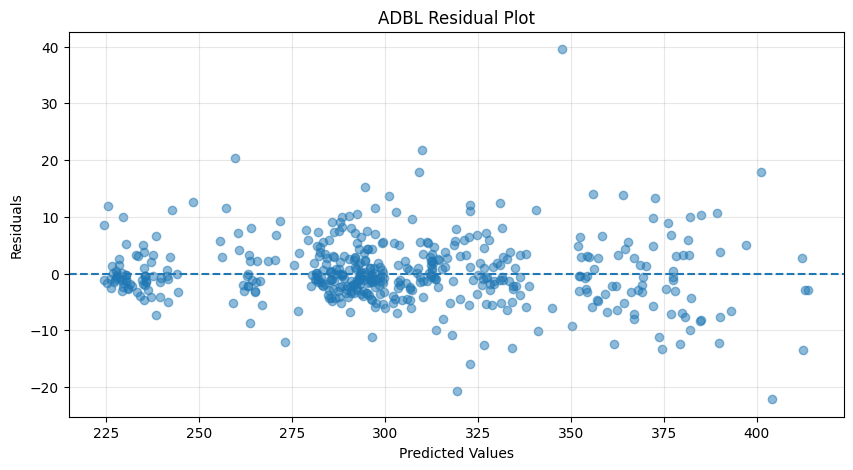

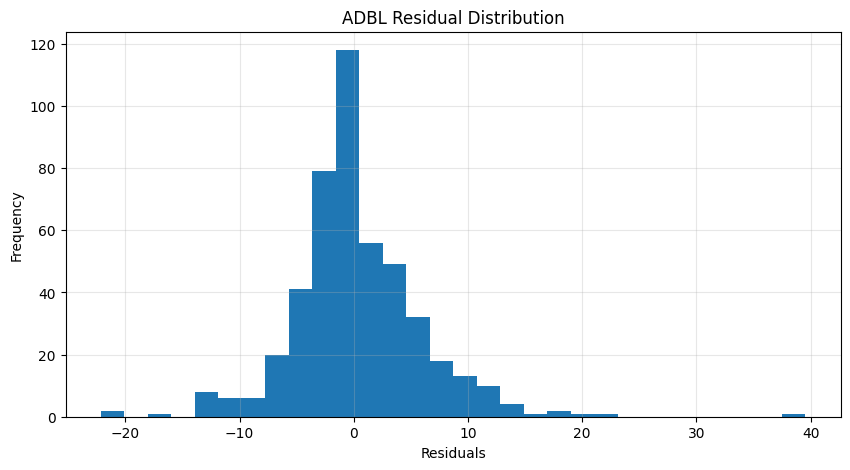

Tomorrow price: 303.02
sent to backend
done ADBL

===== Processing API =====


/mnt/d/spa/python/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,241 (196.25 KB)

 Trainable params: 50,241 (196.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0200 - val_loss: 2.8416e-04
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0038 - val_loss: 3.9044e-04
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0031 - val_loss: 0.0013
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0031 - val_loss: 2.9983e-04
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0029 - val_loss: 2.6037e-04
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0025 - val_loss: 2.0999e-04
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0027 - val_loss: 1.8245e-04
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0025 - val_loss: 2.4516e-04
Epoch 9/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0019 - val_loss: 2.8392e-04
Epoch 10/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0021 - val_loss: 2.0617e-04
Epoch 11/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0021 - val_loss: 1.8647e-04
Epoch 12/100

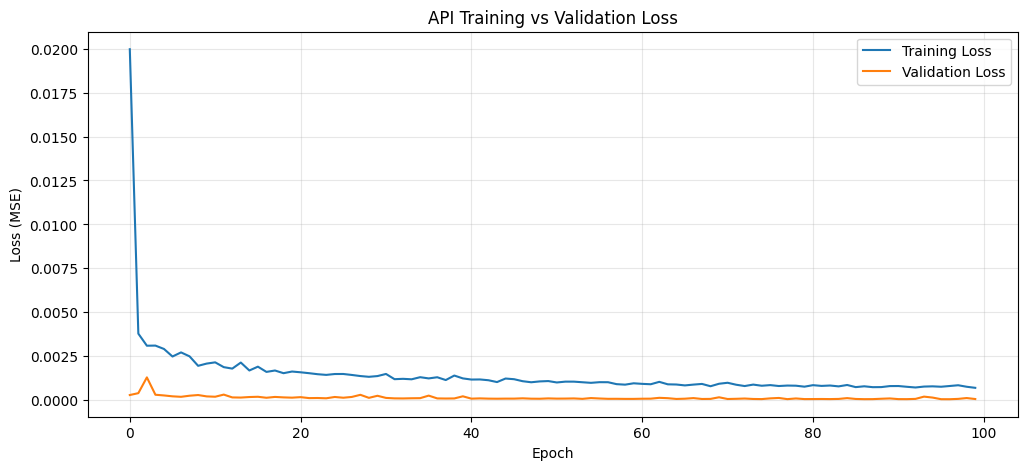

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
MSE:32.13 RMSE:5.67 MAE:4.07 MAPE:1.41% R2:0.8174


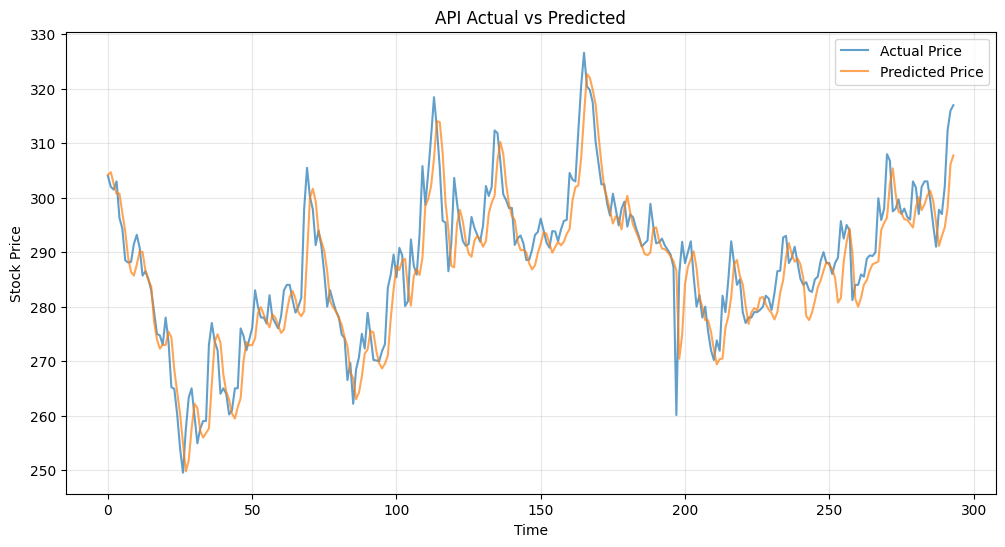

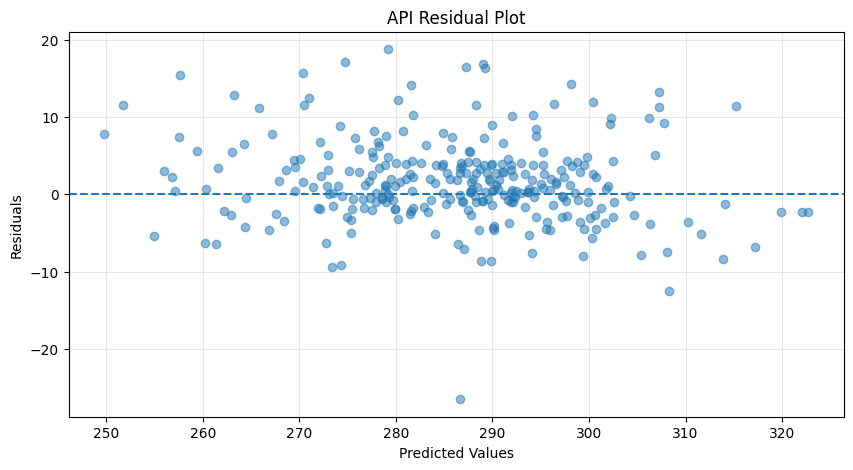

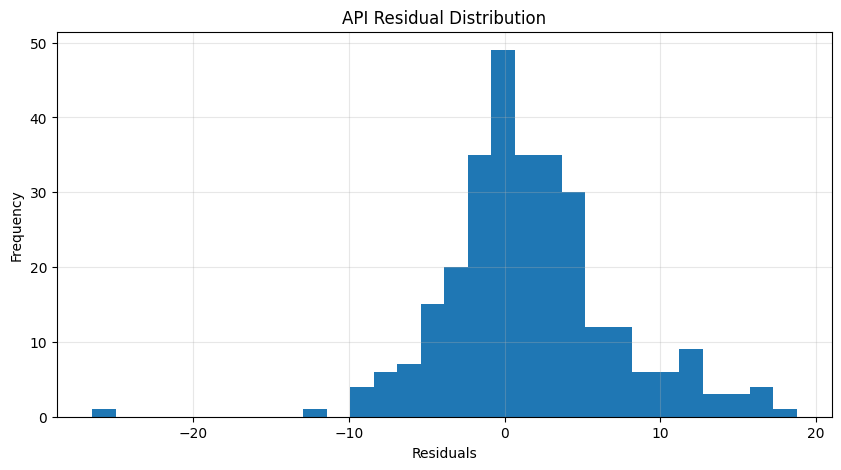

Tomorrow price: 310.43
sent to backend
done API

===== Processing HATH =====

===== Processing HATHPO =====

===== Processing AKPL =====

===== Processing AHPC =====

===== Processing ALICL =====

===== Processing ALICLP =====

===== Processing BOKL =====

===== Processing BOKLPO =====

===== Processing BARUN =====


/mnt/d/spa/python/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,241 (196.25 KB)

 Trainable params: 50,241 (196.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0105 - val_loss: 0.0011
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0033 - val_loss: 7.9849e-04
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0027 - val_loss: 6.4740e-04
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0030 - val_loss: 5.3854e-04
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0028 - val_loss: 8.0503e-04
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0025 - val_loss: 0.0014
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - loss: 0.0024 - val_loss: 6.0835e-04
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0022 - val_loss: 4.8475e-04
Epoch 9/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0021 - val_loss: 4.3880e-04
Epoch 10/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0020 - val_loss: 4.1119e-04
Epoch 11/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0019 - val_loss: 4.7241e-04
Epoch 12/100
48

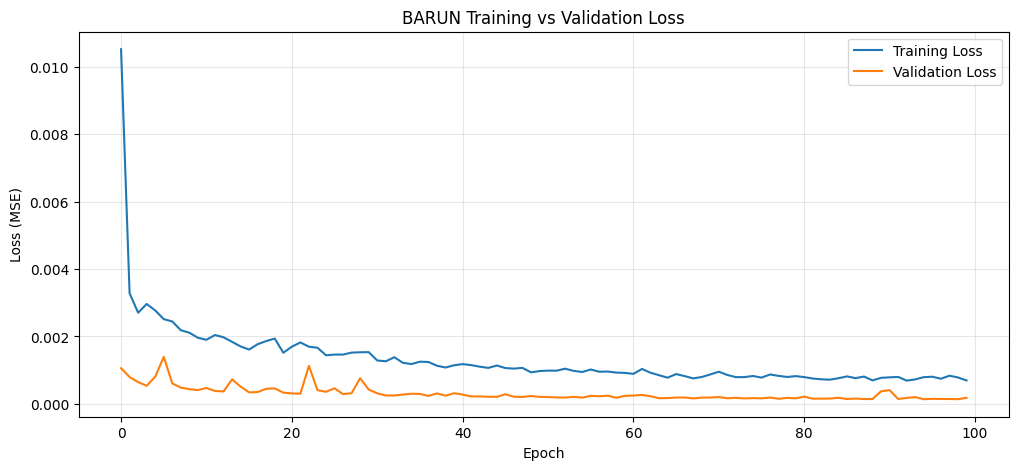

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
MSE:186.79 RMSE:13.67 MAE:8.29 MAPE:2.09% R2:0.9698


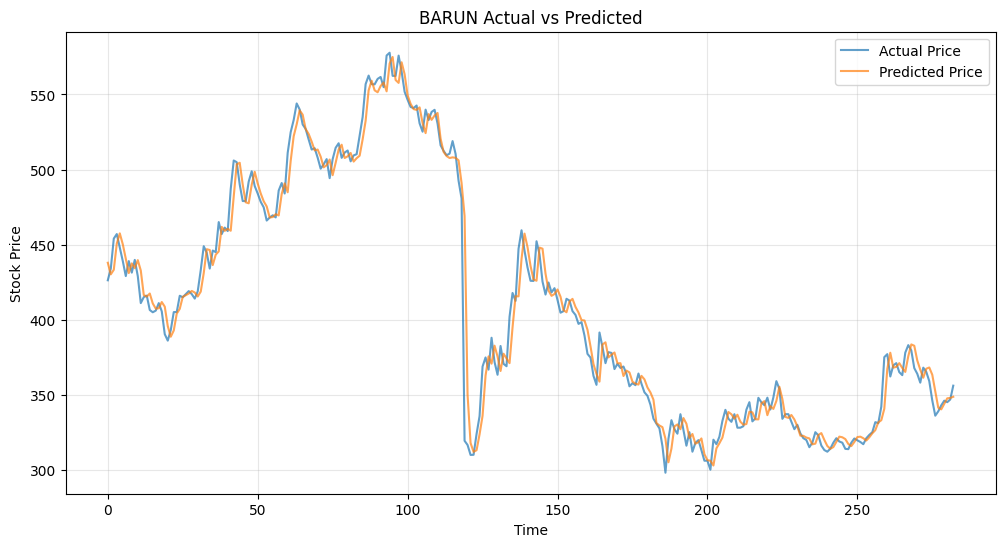

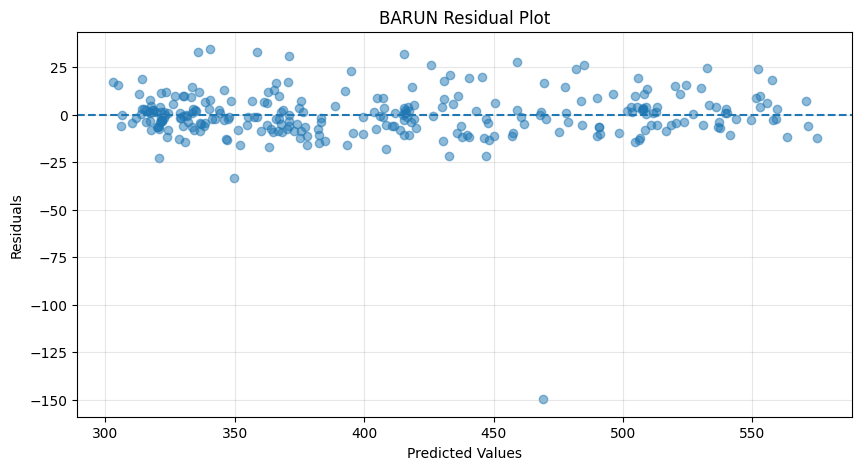

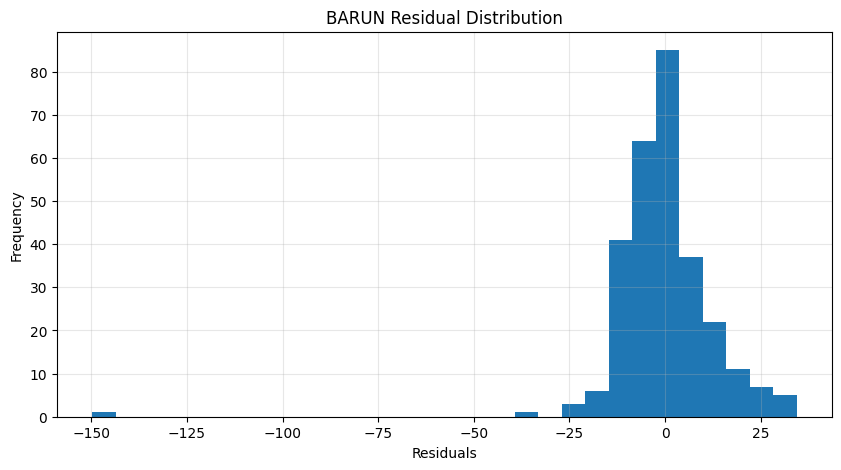

Tomorrow price: 355.26
sent to backend
done BARUN

===== Processing BFC =====

===== Processing BFCPO =====

===== Processing BHBL =====

===== Processing BHBLPO =====

===== Processing BBC =====

===== Processing BNT =====

===== Processing BNL =====

===== Processing BUDBL =====

===== Processing BUDBLP =====

===== Processing BPCL =====

===== Processing CFCL =====

===== Processing CFCLPO =====

===== Processing CCBL =====

===== Processing CCBLPO =====

===== Processing CBBL =====

===== Processing CHL =====

===== Processing CHCL =====

===== Processing CIT =====

===== Processing CZBIL =====

===== Processing CZBILP =====

===== Processing CBL =====

===== Processing CBLPO =====

===== Processing HLBSL =====

===== Processing CORBL =====

===== Processing CORBLP =====

===== Processing DDBL =====

===== Processing DDBLPO =====

===== Processing DBBL =====

===== Processing DBBLPO =====

===== Processing DHPL =====

===== Processing EBL =====

===== Processing EBLPO =====

===== 

/mnt/d/spa/python/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,241 (196.25 KB)

 Trainable params: 50,241 (196.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.0176 - val_loss: 3.5041e-04
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0037 - val_loss: 3.0255e-04
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0032 - val_loss: 3.5633e-04
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0028 - val_loss: 4.1253e-04
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0028 - val_loss: 4.1621e-04
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0026 - val_loss: 4.6127e-04
Epoch 7/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0028 - val_loss: 4.7607e-04
Epoch 8/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0023 - val_loss: 2.9742e-04
Epoch 9/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0022 - val_loss: 2.6411e-04
Epoch 10/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0024 - val_loss: 6.0492e-04
Epoch 11/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0021 - val_loss: 2.7973e-04
Epoch 12

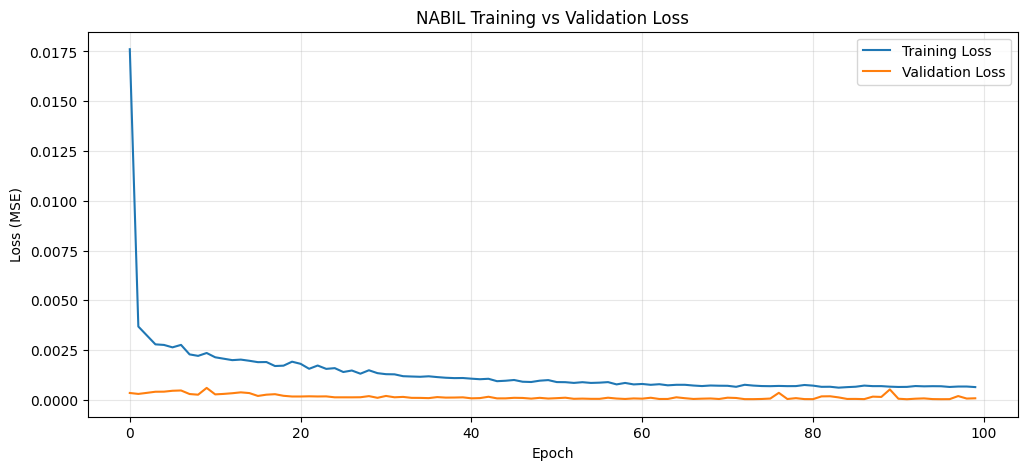

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
MSE:89.81 RMSE:9.48 MAE:6.18 MAPE:1.19% R2:0.9599


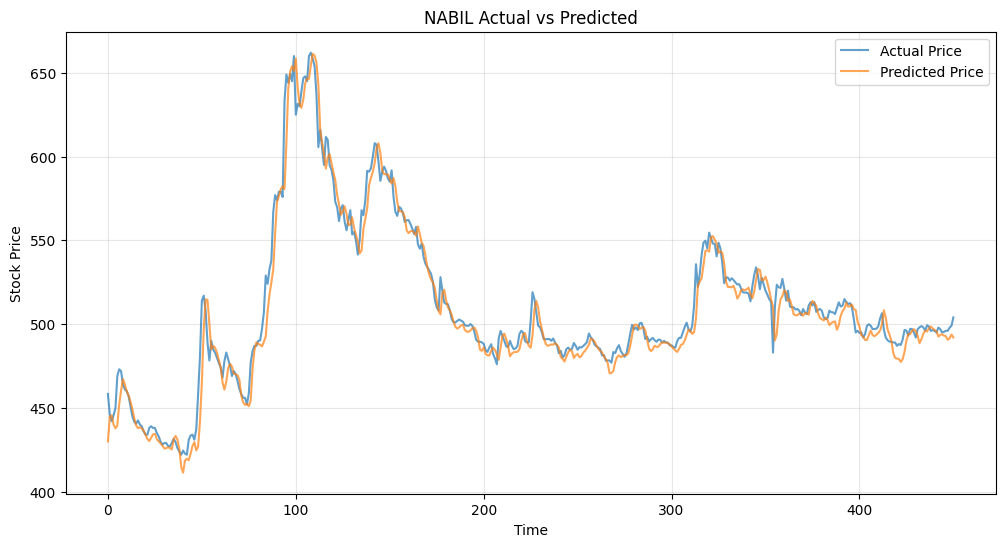

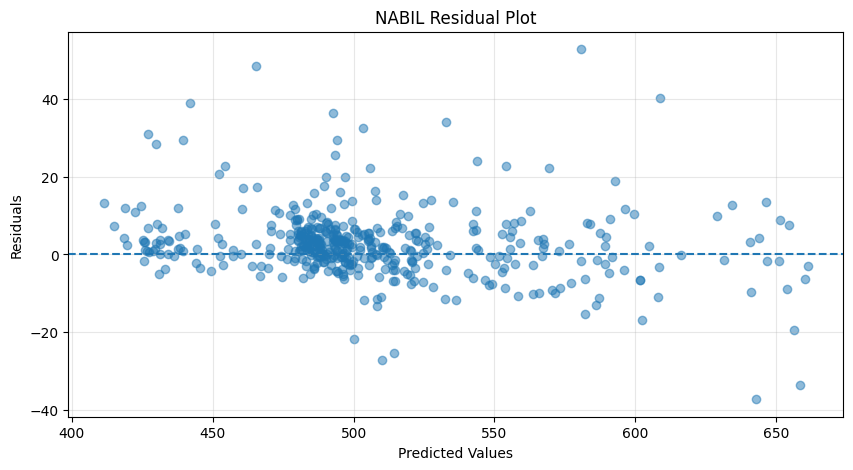

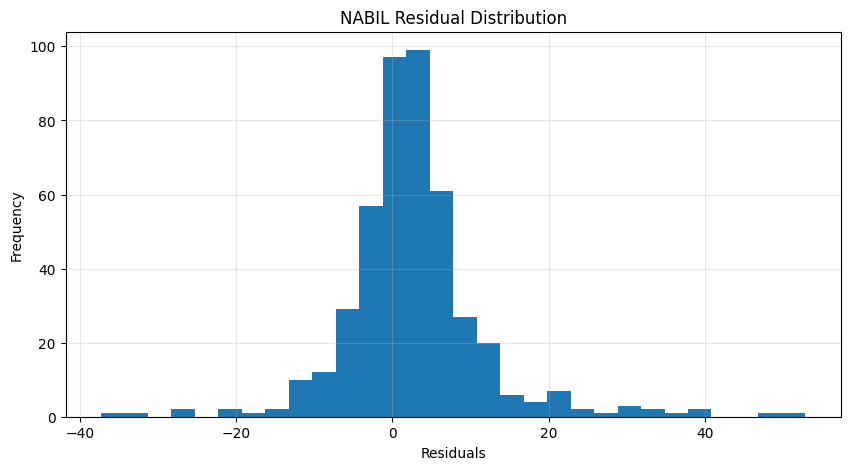

Tomorrow price: 496.96
sent to backend
done NABIL

===== Processing NABILP =====

===== Processing NEF =====

===== Processing NBBL =====

===== Processing NBBLPO =====

===== Processing NBSL =====

===== Processing NHPC =====

===== Processing NLICL =====

===== Processing NLICLP =====

===== Processing NMLBS =====

===== Processing NNLB =====

===== Processing NIL =====

===== Processing NILPO =====

===== Processing NABB =====

===== Processing NABBPO =====

===== Processing NBB =====

===== Processing NBBPO =====

===== Processing NBL =====

===== Processing NCDB =====

===== Processing NCDBPO =====

===== Processing NCCB =====

===== Processing NCCBPO =====

===== Processing NTC =====


/mnt/d/spa/python/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 60, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,241 (196.25 KB)

 Trainable params: 50,241 (196.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0063 - val_loss: 0.0026
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0014 - val_loss: 0.0022
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0012 - val_loss: 0.0019
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0011 - val_loss: 0.0017
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0010 - val_loss: 0.0017
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 8.5868e-04 - val_loss: 0.0016
Epoch 7/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 8.7388e-04 - val_loss: 0.0013
Epoch 8/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 7.2684e-04 - val_loss: 0.0013
Epoch 9/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 7.5514e-04 - val_loss: 0.0011
Epoch 10/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 7.3210e-04 - val_loss: 0.0013
Epoch 11/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 7.7118e-04 - val_loss: 0.0012
Epoch 12/100
73/73 ━━━━━━━━━

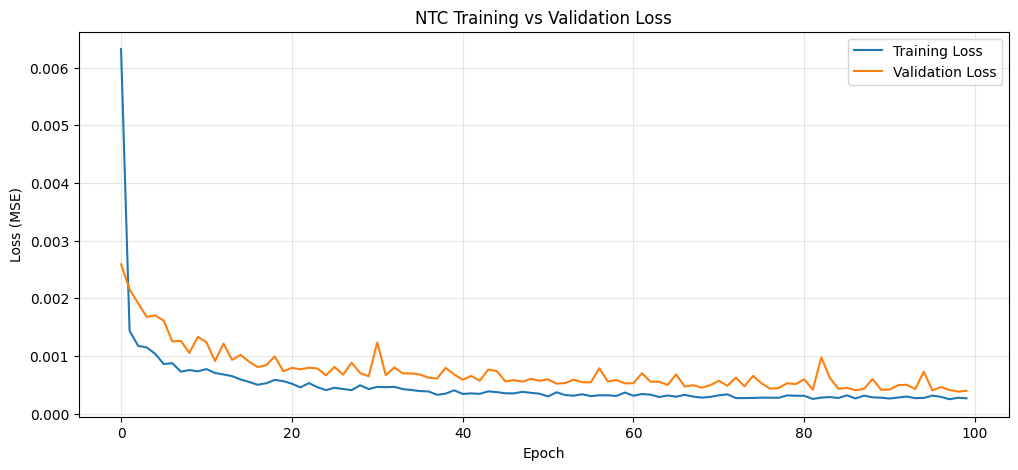

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
MSE:157.35 RMSE:12.54 MAE:8.70 MAPE:0.95% R2:0.9565


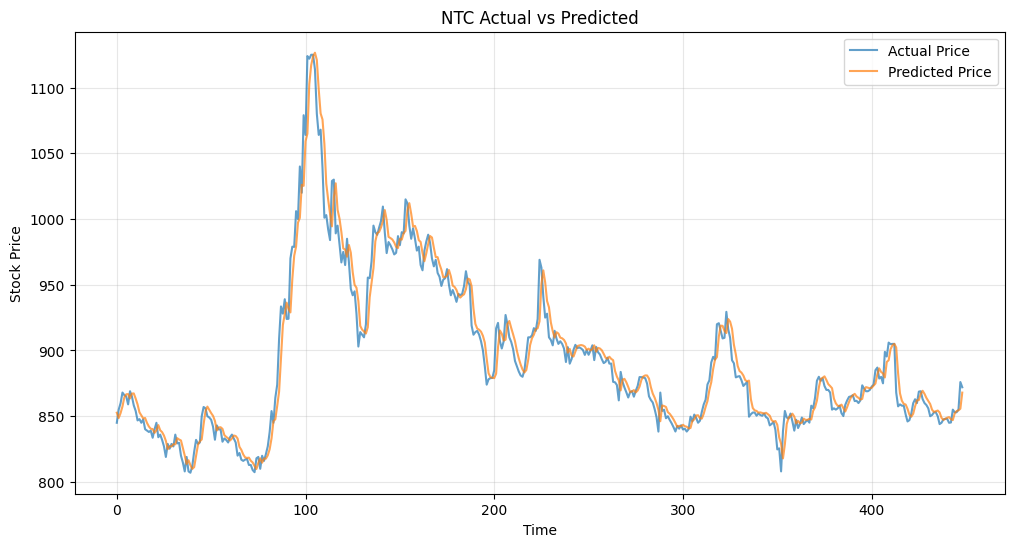

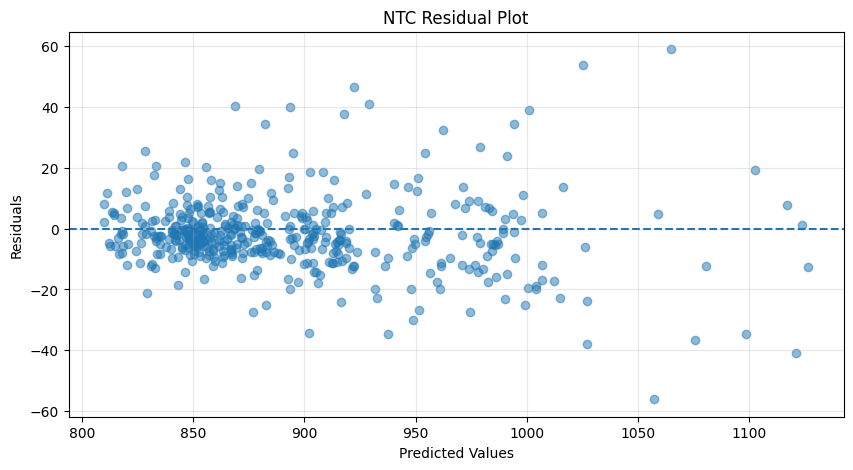

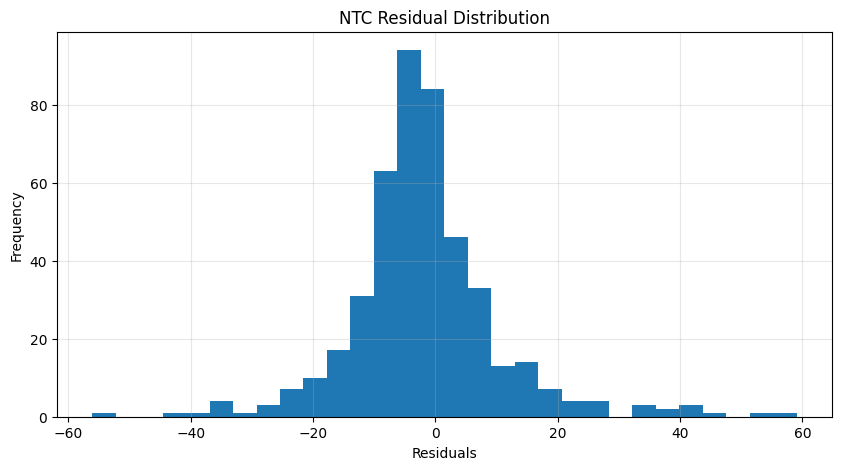

Tomorrow price: 872.23
sent to backend
done NTC

===== Processing GBLBS =====

===== Processing GBLBSP =====

===== Processing NHDL =====

===== Processing NICL =====

===== Processing NIB =====

===== Processing NIBPO =====

===== Processing NLIC =====

===== Processing NLICP =====

===== Processing SBI =====

===== Processing SBIPO =====

===== Processing NLBBL =====

===== Processing NGPL =====

===== Processing NIBLPF =====

===== Processing NIBSF1 =====

===== Processing NICA =====


/mnt/d/spa/python/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 60, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,241 (196.25 KB)

 Trainable params: 50,241 (196.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 0.0213 - val_loss: 0.0027
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0048 - val_loss: 0.0025
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 0.0042 - val_loss: 0.0021
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0041 - val_loss: 0.0020
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0036 - val_loss: 0.0019
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0037 - val_loss: 0.0017
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0036 - val_loss: 0.0015
Epoch 8/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0032 - val_loss: 0.0014
Epoch 9/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0030 - val_loss: 0.0017
Epoch 10/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0034 - val_loss: 0.0013
Epoch 11/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0031 - val_loss: 0.0016
Epoch 12/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step

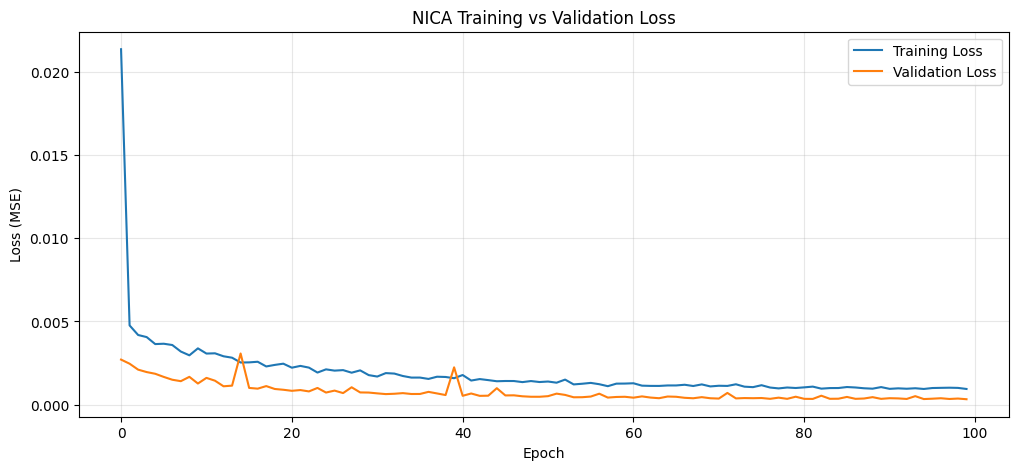

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
MSE:79.38 RMSE:8.91 MAE:6.18 MAPE:1.57% R2:0.9765


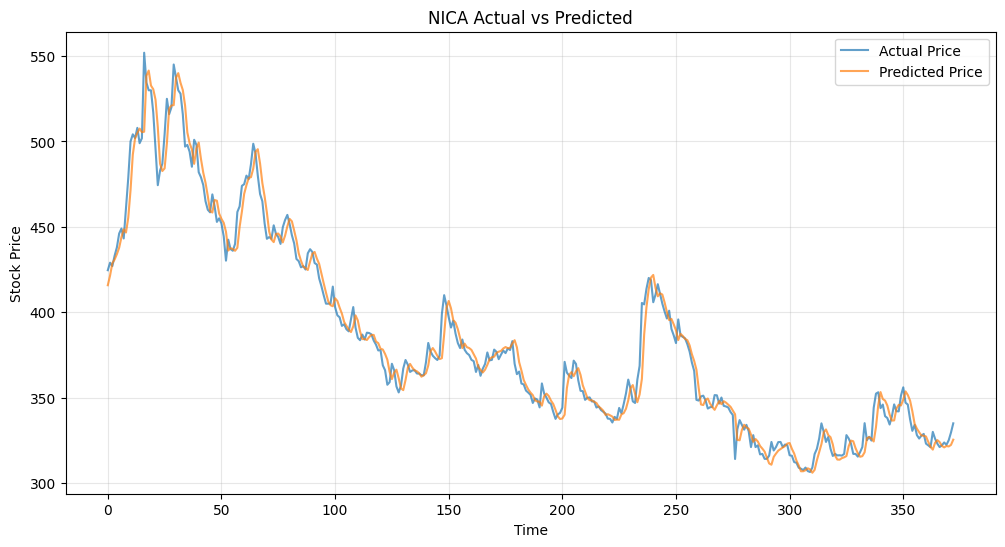

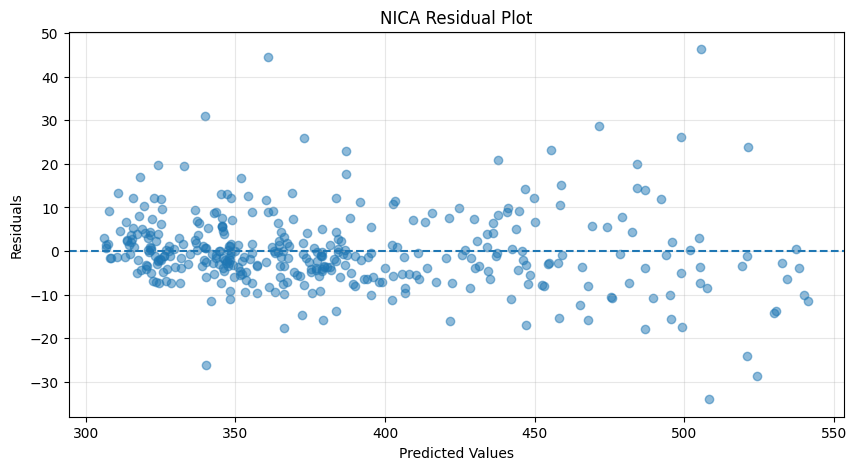

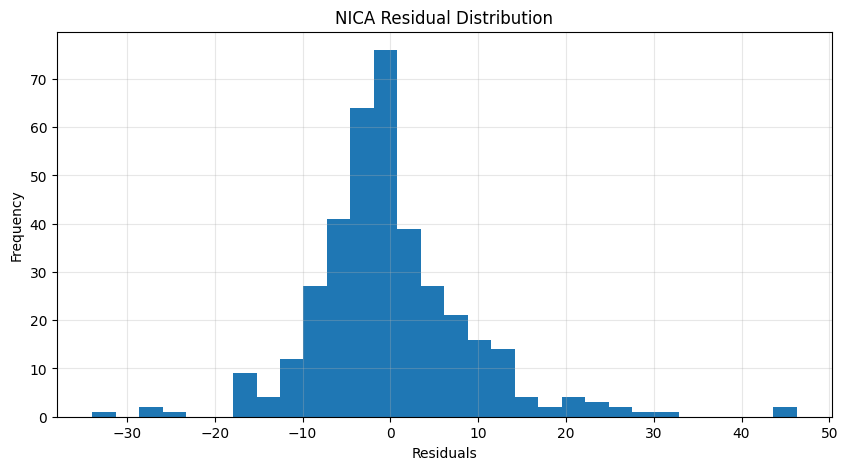

Tomorrow price: 330.27
sent to backend
done NICA

===== Processing NICAP =====

===== Processing NIDC =====

===== Processing NUBL =====

===== Processing NLG =====

===== Processing NMB =====

===== Processing NMBPO =====

===== Processing NMBMF =====

===== Processing NMBSF1 =====

===== Processing ODBL =====

===== Processing ODBLPO =====

===== Processing OHL =====

===== Processing PFL =====

===== Processing PFLPO =====

===== Processing PRVU =====

===== Processing PRVUPO =====

===== Processing PRIN =====

===== Processing PRINPO =====

===== Processing PIC =====

===== Processing PCBL =====

===== Processing PCBLP =====

===== Processing PLIC =====

===== Processing PLICPO =====

===== Processing PROFL =====

===== Processing PROFLP =====

===== Processing PICL =====

===== Processing PICLPO =====

===== Processing PURBL =====

===== Processing PURBLP =====

===== Processing RBCL =====

===== Processing RBCLPO =====

===== Processing RLFL =====

===== Processing RLFLPO =====



In [6]:
# ================= MAIN LOOP =================
for symbol in symbols:
    print(f"\n===== Processing {symbol} =====")

    if symbol not in needCompareModel:
        continue

    if symbol in stock_ignored:
        continue

    symbol_path = os.path.join(BASE_DIR, symbol)
    os.makedirs(symbol_path, exist_ok=True)

    stock_path = f"../DATA-HTML-STOCK/NEPSEDATA/{symbol}.csv"
    final_path = f"../DATA-HTML-STOCK/FinalDataSet/{symbol}.csv"
    model_path = os.path.join(MODELS_DIR, f"{symbol}_lstm.h5")

    if not os.path.exists(stock_path) or not os.path.exists(final_path):
        print(f"{symbol} missing data")
        continue

    # ================= LOAD STOCK =================
    stock_df = pd.read_csv(stock_path)
    stock_df = stock_df[['Date', 'Close']].dropna()
    stock_df['Close'] = stock_df['Close'].astype(str).str.replace(',', '').astype(float)
    stock_df['Date'] = pd.to_datetime(stock_df['Date'])

    # ================= LOAD SENTIMENT =================
    sentiment_df = pd.read_csv(final_path)
    sentiment_df = sentiment_df[['Date_Stock', 'Decayed_Sentiment']]
    sentiment_df['Date_Stock'] = pd.to_datetime(sentiment_df['Date_Stock'])

    # ================= MERGE =================
    data = pd.merge(stock_df, sentiment_df, left_on='Date', right_on='Date_Stock', how='left')
    data = data[['Date', 'Close', 'Decayed_Sentiment']]

    if symbol in stock_no_news:
        data['Decayed_Sentiment'] = 0.0
    else:
        data['Decayed_Sentiment'] = data['Decayed_Sentiment'].fillna(0.0)

    data = data.dropna(subset=['Close'])
    data = data.sort_values("Date").reset_index(drop=True)

    if len(data) < TIME_STEPS + 10:
        print(f"{symbol} not enough data")
        continue

    current_price = data['Close'].iloc[-1]

    # ================= SCALING =================
    values = data[['Close', 'Decayed_Sentiment']].values
    scaler = MinMaxScaler()
    scaled_all = scaler.fit_transform(values)

    # ================= SPLIT =================
    train_size = int(0.7 * len(scaled_all))
    val_size   = int(0.15 * len(scaled_all))

    train_data = scaled_all[:train_size]
    val_data   = scaled_all[train_size:train_size+val_size]
    test_data  = scaled_all[train_size+val_size:]

    # ================= SEQUENCES =================
    X_train, y_train = create_sequences(train_data, TIME_STEPS)
    X_val,   y_val   = create_sequences(val_data, TIME_STEPS)
    X_test,  y_test  = create_sequences(test_data, TIME_STEPS)

    if len(X_train) == 0 or len(X_test) == 0:
        print(f"{symbol} insufficient sequences")
        continue

    # ================= MODEL =================
    if os.path.exists(model_path):
        model = load_model(model_path)
        history = None
    else:
        model = build_model(TIME_STEPS, 2)

        early_stop = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

        history = model.fit(
            X_train, y_train,
            epochs=epochIs,
            batch_size=batchsize,
            validation_data=(X_val, y_val),
            callbacks=[early_stop],
            verbose=1
        )

        if history is not None:
            plt.figure(figsize=(12, 5))
            plt.plot(history.history['loss'], label='Training Loss')
            plt.plot(history.history['val_loss'], label='Validation Loss')
            plt.xlabel('Epoch')
            plt.ylabel('Loss (MSE)')
            plt.title(f"{symbol} Training vs Validation Loss")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.savefig(os.path.join(symbol_path, "training_loss.png"), dpi=300)
            plt.show()
            plt.close()

        model.save(model_path)

    # ================= PREDICTION =================
    predictions = model.predict(X_test)

    # correct inverse scaling
    dummy_pred = np.zeros((len(predictions), 2))
    dummy_pred[:, 0] = predictions.flatten()
    predictions_actual = scaler.inverse_transform(dummy_pred)[:, 0]

    dummy_y = np.zeros((len(y_test), 2))
    dummy_y[:, 0] = y_test.flatten()
    y_test_actual = scaler.inverse_transform(dummy_y)[:, 0]

    
    mse = mean_squared_error(y_test_actual, predictions_actual)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test_actual, predictions_actual)
    mape = np.mean(np.abs((y_test_actual - predictions_actual) / y_test_actual)) * 100
    r2   = r2_score(y_test_actual, predictions_actual)

    print(f"MSE:{mse:.2f} RMSE:{rmse:.2f} MAE:{mae:.2f} MAPE:{mape:.2f}% R2:{r2:.4f}")

    
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_actual, label='Actual Price', alpha=0.7)
    plt.plot(predictions_actual, label='Predicted Price', alpha=0.7)
    plt.xlabel("Time")
    plt.ylabel("Stock Price")
    plt.title(f"{symbol} Actual vs Predicted")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(symbol_path, "prediction.png"), dpi=300)
    plt.show()
    plt.close()

    
    residuals = y_test_actual - predictions_actual
    plt.figure(figsize=(10, 5))
    plt.scatter(predictions_actual, residuals, alpha=0.5)
    plt.axhline(y=0, linestyle='--')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title(f"{symbol} Residual Plot")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(symbol_path, "residual_plot.png"), dpi=300)
    plt.show()
    plt.close()

    
    plt.figure(figsize=(10, 5))
    plt.hist(residuals, bins=30)
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.title(f"{symbol} Residual Distribution")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(symbol_path, "residual_hist.png"), dpi=300)
    plt.show()
    plt.close()

    # ================= TOMORROW PREDICTION =================
    last_60 = scaled_all[-TIME_STEPS:]
    last_60 = last_60.reshape(1, TIME_STEPS, 2)

    tomorrow_scaled = model.predict(last_60, verbose=0)
    dummy_next = np.zeros((1, 2))
    dummy_next[0, 0] = tomorrow_scaled[0, 0]

    tomorrow_price = scaler.inverse_transform(dummy_next)[0, 0]

    print(f"Tomorrow price: {tomorrow_price:.2f}")

    # ================= SAVE =================
    metrics = {
        "symbol": symbol,
        "current_price": float(current_price),
        "tomorrow_price": float(tomorrow_price),
        "mse": float(mse),
        "rmse": float(rmse),
        "mae": float(mae),
        "mape": float(mape),
        "r2": float(r2)
    }

    with open(os.path.join(symbol_path, "metrics.json"), "w") as f:
        json.dump(metrics, f, indent=4)

    
    try:
        requests.post('http://192.168.254.6:3000/predicted_price',json={"predicted_price": float(tomorrow_price),"stock": symbol,"date": data['Date'].iloc[-1].strftime('%Y-%m-%d'),"current_price": current_price})
        print("sent to backend")
    except Exception as e:
        print("API error:", e)

    print(f"done {symbol}")

print("\nAll stocks processed successfully.")